In [36]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
num_rows = 500
data = {
    "num_assets": np.random.randint(5000, 20000, num_rows),  # Varying asset count
    "num_customers": np.random.randint(50, 500, num_rows),  # Varying customer count
    "memory_gb": np.random.choice([8, 16, 32, 64], num_rows),  # Common memory sizes
    "cpu_cores": np.random.choice([2, 4, 8, 16], num_rows),  # Common CPU configurations
    "first_x": np.random.randint(10, 90, num_rows),  # Random first_x values
    "gets_y": np.random.randint(10, 90, num_rows),  # Random gets_y values
}

# Generate num_simulators with a linear relation + some randomness
weights = np.array([0.0005, 0.002, 0.1, 0.2, -0.05, 0.05])  # Assumed relationships
features_matrix = np.column_stack([data[col] for col in data.keys()])
num_simulators = (features_matrix @ weights + np.random.normal(0, 2, num_rows)).astype(int)
num_simulators = np.clip(num_simulators, 5, 50)  # Ensuring reasonable bounds

data["num_simulators"] = num_simulators

df = pd.DataFrame(data)

# Save to CSV
csv_filename = "num_simulators.csv"
df.to_csv(csv_filename, index=False)

print(f"Generated dataset saved as {csv_filename}")
print(df.head())


Generated dataset saved as num_simulators.csv
   num_assets  num_customers  memory_gb  cpu_cores  first_x  gets_y  \
0       12270            348         64          4       22      17   
1        5860            295          8          2       27      10   
2       10390            225         16         16       41      17   
3       18418             88         64          8       48      38   
4       10191            219          8          4       55      14   

   num_simulators  
0              13  
1               5  
2               9  
3              14  
4               5  


In [37]:
import pandas as pd

# Load CSV file
df = pd.read_csv("num_simulators.csv")

# Display basic info
print(df.info())

# Show first few rows
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   num_assets      500 non-null    int64
 1   num_customers   500 non-null    int64
 2   memory_gb       500 non-null    int64
 3   cpu_cores       500 non-null    int64
 4   first_x         500 non-null    int64
 5   gets_y          500 non-null    int64
 6   num_simulators  500 non-null    int64
dtypes: int64(7)
memory usage: 27.5 KB
None
   num_assets  num_customers  memory_gb  cpu_cores  first_x  gets_y  \
0       12270            348         64          4       22      17   
1        5860            295          8          2       27      10   
2       10390            225         16         16       41      17   
3       18418             88         64          8       48      38   
4       10191            219          8          4       55      14   

   num_simulators  
0              13 

In [38]:
# Summary statistics
print(df.describe())


         num_assets  num_customers   memory_gb   cpu_cores     first_x  \
count    500.000000     500.000000  500.000000  500.000000  500.000000   
mean   12411.718000     274.032000   29.440000    7.012000   49.820000   
std     4290.047562     128.652329   20.921611    5.074975   23.265299   
min     5064.000000      50.000000    8.000000    2.000000   10.000000   
25%     8615.500000     168.750000   16.000000    2.000000   29.000000   
50%    12362.000000     270.500000   16.000000    4.000000   50.000000   
75%    16206.250000     390.250000   32.000000    8.000000   69.250000   
max    19948.000000     499.000000   64.000000   16.000000   89.000000   

           gets_y  num_simulators  
count  500.000000      500.000000  
mean    48.076000       10.604000  
std     23.626906        3.884503  
min     10.000000        5.000000  
25%     28.000000        7.750000  
50%     45.500000       10.000000  
75%     69.000000       13.000000  
max     89.000000       24.000000  


In [39]:
print(df.isnull().sum())  # Check missing values


num_assets        0
num_customers     0
memory_gb         0
cpu_cores         0
first_x           0
gets_y            0
num_simulators    0
dtype: int64


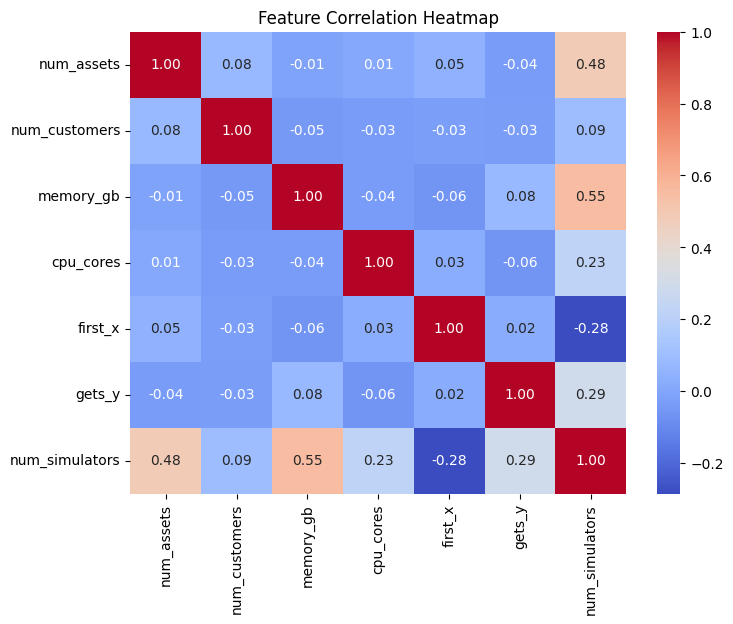

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


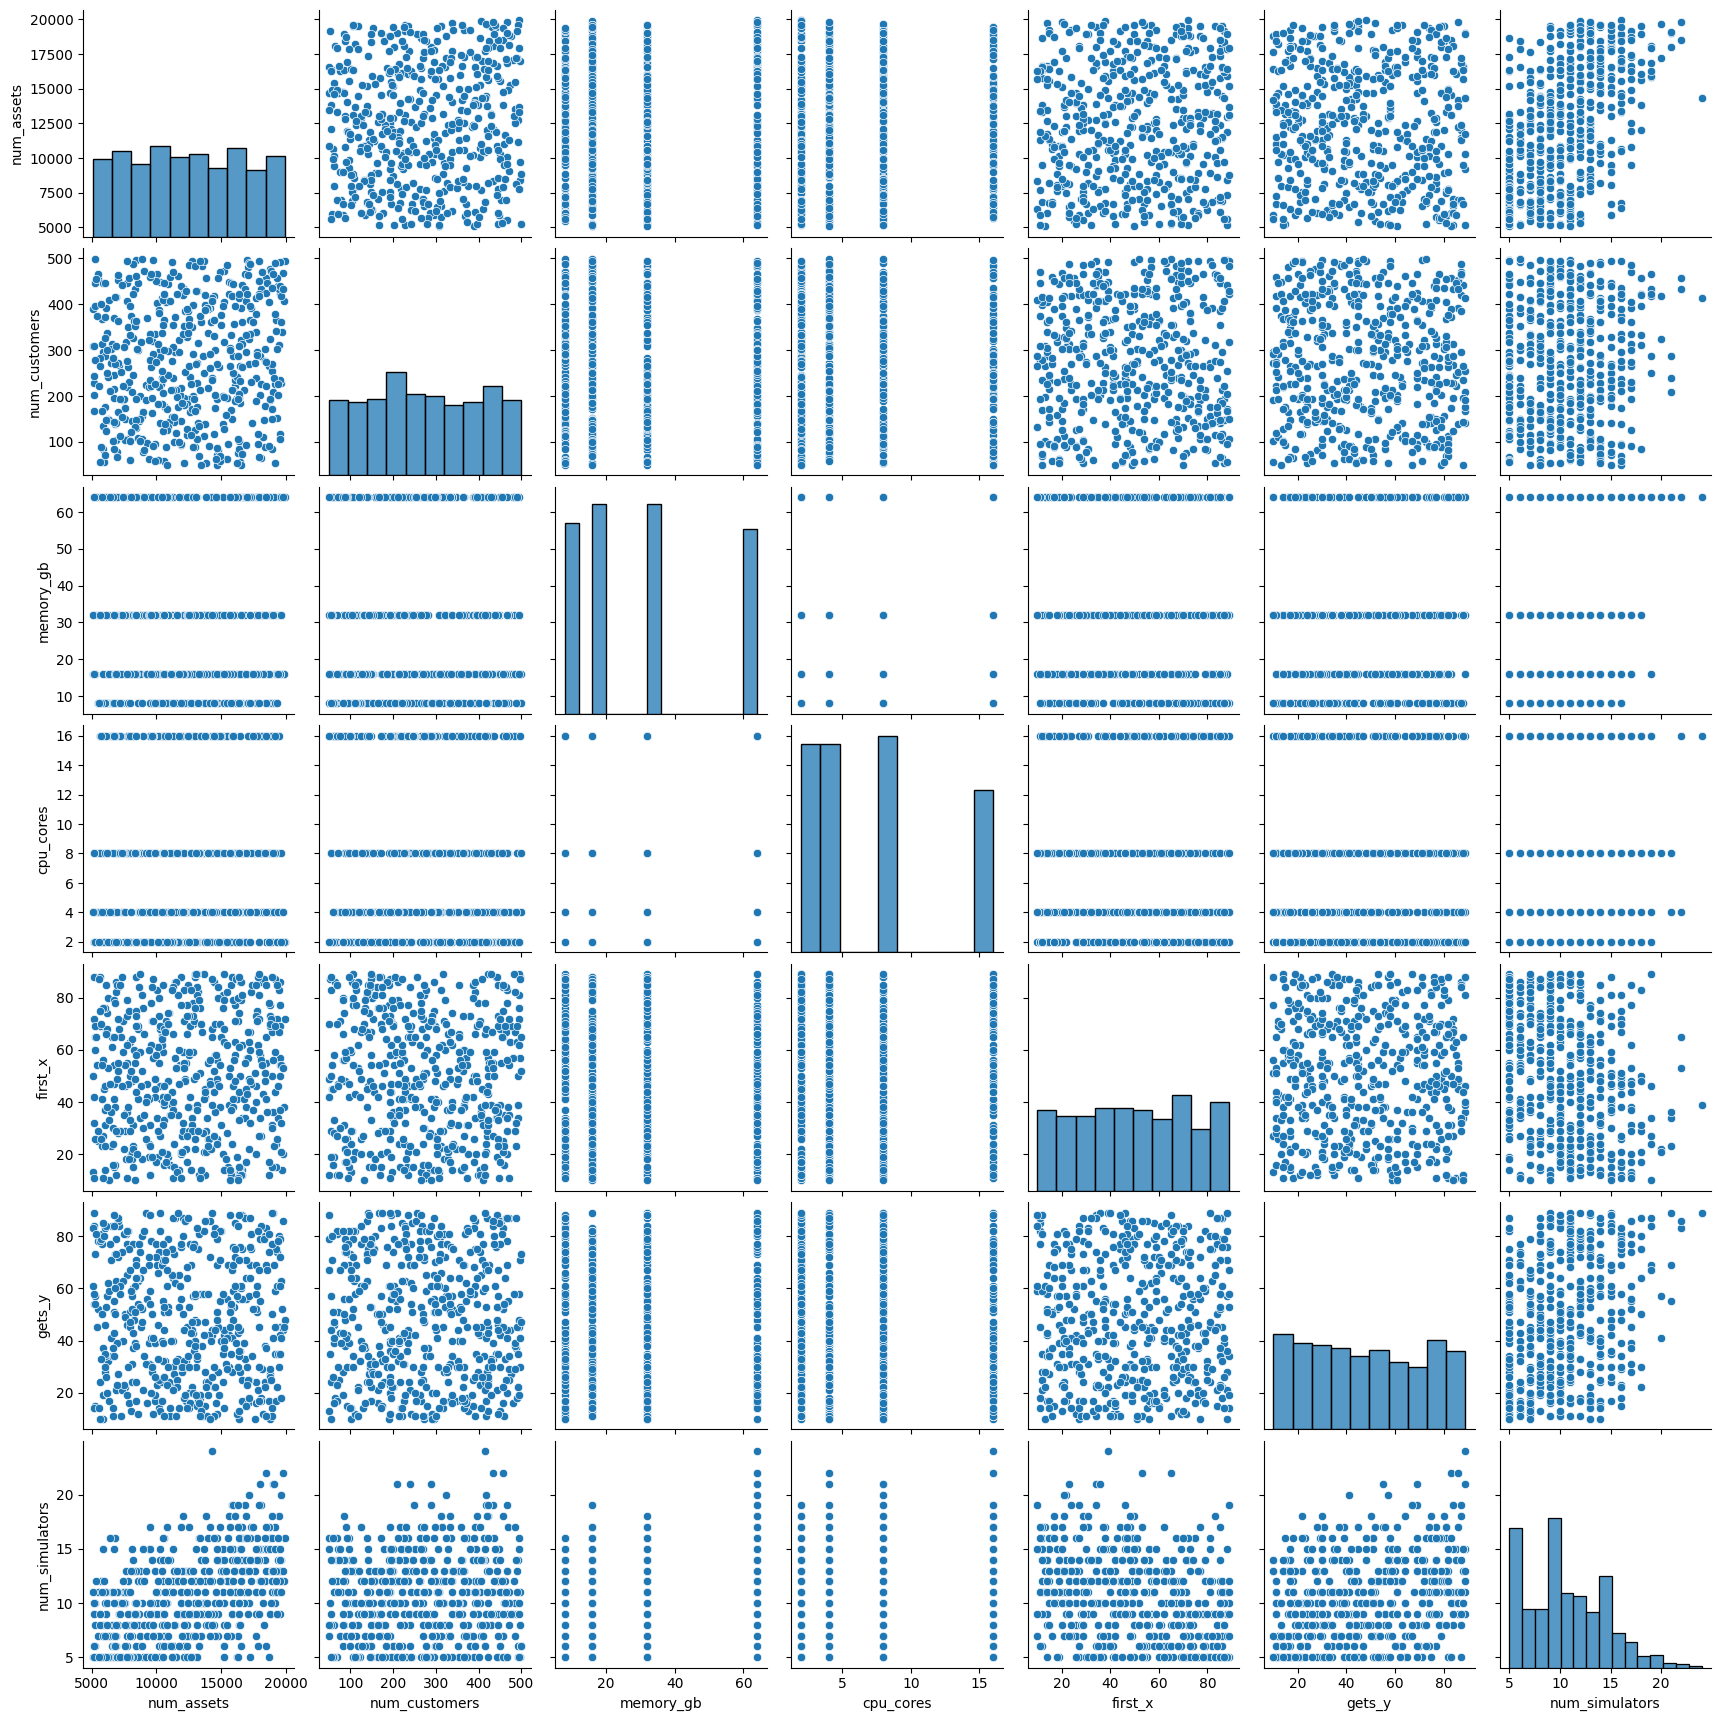

In [41]:
sns.pairplot(df)
plt.show()


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define input (X) and target (y)
X = df.drop(columns=["num_simulators"])
y = df["num_simulators"]

# Split data into training & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.3f}")
print(f"R² Score: {r2:.3f}")


Mean Squared Error: 3.228
R² Score: 0.774


In [43]:
import numpy as np

# Example new data point (replace with actual values)
new_point = np.array([[10000, 100, 8, 4, 40, 60]])  # Example input

# Predict num_simulators
prediction = model.predict(new_point)
print(f"Predicted num_simulators: {prediction[0]:.2f}")


Predicted num_simulators: 7.38


/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Ridge Regression:
Mean Squared Error: 3.739
R² Score: 0.738

Lasso Regression:
Mean Squared Error: 3.548
R² Score: 0.752


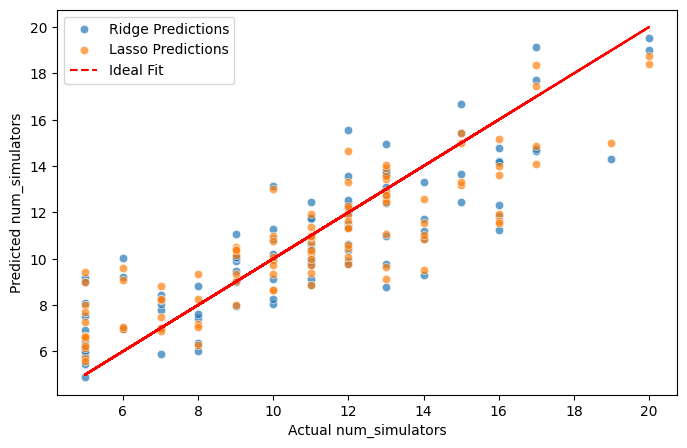

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Load data
data = pd.read_csv("num_simulators.csv")

# Feature Engineering: Adding Interaction Terms
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(data.drop(columns=["num_simulators"]))

# Scaling Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

y = data["num_simulators"]

# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Apply Regularized Regression Models
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# Predictions
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

# Evaluation
print("Ridge Regression:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_ridge):.3f}")
print(f"R² Score: {r2_score(y_test, y_pred_ridge):.3f}\n")

print("Lasso Regression:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_lasso):.3f}")
print(f"R² Score: {r2_score(y_test, y_pred_lasso):.3f}")

# Visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_ridge, label='Ridge Predictions', alpha=0.7)
sns.scatterplot(x=y_test, y=y_pred_lasso, label='Lasso Predictions', alpha=0.7)
plt.plot(y_test, y_test, color='red', linestyle='dashed', label='Ideal Fit')
plt.xlabel("Actual num_simulators")
plt.ylabel("Predicted num_simulators")
plt.legend()
plt.show()


In [45]:
import joblib
# Save models
joblib.dump(ridge, "ridge_model.pkl")
joblib.dump(lasso, "lasso_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(poly, "poly.pkl")

['poly.pkl']